####  Importer les bibliothèques nécessaires


In [1]:
import numpy as np
import pandas
import numpy as vnp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('C:\\Users\\ec\\OneDrive\\Bureau\\PROJET_MLOPS\\Loan_Data.csv')


#### Afficher les premières lignes du DataFrame pour inspecter les données

In [3]:
print("Aperçu des données :")
print(df.head())

Aperçu des données :
   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  


####    Gérer les valeurs manquantes

In [4]:
# Méthode : Remplacer les valeurs manquantes par la médiane (pour les variables numériques) et par le mode (pour les variables catégorielles)
for column in df.columns:
    if df[column].dtype == 'object':  # Si la colonne est catégorielle
        df[column].fillna(df[column].mode()[0], inplace=True)  # Remplacer par le mode
    else:
        df[column].fillna(df[column].median(), inplace=True)  # Remplacer par la médiane


C:\Users\ec\AppData\Local\Temp\ipykernel_17160\459154469.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(), inplace=True)  # Remplacer par la médiane
C:\Users\ec\AppData\Local\Temp\ipykernel_17160\459154469.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [5]:
# Vérifier s'il reste des valeurs manquantes
print("\nValeurs manquantes après traitement :")
print(df.isnull().sum())


Valeurs manquantes après traitement :
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64


Cela signifie que toutes les informations nécessaires sont maintenant présentes pour chaque client dans ces colonnes.

### Pré-traitement des données

#### Encodage des variables catégorielles

In [6]:
# Utilisation de LabelEncoder pour transformer les colonnes catégorielles en valeurs numériques
label_encoders = {}
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le


#### Normalisation ou standardisation

In [7]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Utilisation de StandardScaler pour standardiser les variables numériques
scaler = StandardScaler()
numeric_columns = df.select_dtypes(include=[np.number]).columns  # Sélectionner uniquement les colonnes numériques
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# Gestion des doublons
df.drop_duplicates(inplace=True)

#  Afficher les données pré-traitées
print("\nAperçu des données pré-traitées :")
print(df.head())

#  Sauvegarder les données pré-traitées dans un nouveau fichier CSV
df.to_csv('Loan_Data_Preprocessed.csv', index=False)
print("\nLes données pré-traitées ont été enregistrées dans 'Loan_Data_Preprocessed.csv'.")


Aperçu des données pré-traitées :
   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0     1.385836                 -0.837960              0.747096   
1     1.075936                  2.029409             -1.548375   
2    -1.185166                 -0.837960             -0.560509   
3    -0.038627                 -0.837960              0.427045   
4    -0.119438                 -0.264486             -1.979733   

   total_debt_outstanding    income  years_employed  fico_score   default  
0               -0.724848  0.398555        0.285425   -0.536770 -0.476597  
1               -0.073967 -2.161876       -1.629325   -1.080832  2.098210  
2               -1.009696 -0.207919       -0.352825   -0.586230 -0.476597  
3               -0.938184  0.215083        0.285425   -0.421363 -0.476597  
4               -1.048780 -2.321314        0.923675   -0.108115 -0.476597  

Les données pré-traitées ont été enregistrées dans 'Loan_Data_Preprocessed.csv'.


### Model Engineering

In [8]:
# Supprimer la colonne 'customer_id' qui n'est pas pertinente pour la classification
df_cleaned = df.drop(columns=['customer_id'])

La colonne customer_id est un identifiant unique pour chaque client dans le dataset. Elle n'apporte aucune information utile pour la classification des prêts en défaut  - non-défaut parce qu'elle ne représente aucune caractéristique du client qui pourrait influencer le résultat

#### Séparation des caratéristiques et des variables cibles 

In [9]:
# Convertir la variable cible en catégorielle binaire si nécessaire
df_cleaned['default'] = df_cleaned['default'].astype('category')

In [10]:
# Séparer les caractéristiques (X) et la variable cible (y)
X = df_cleaned.drop(columns=['default'])  # Caractéristiques
y = df_cleaned['default']  # Cible

# Diviser les données en ensembles d'entraînement et de test (80% pour l'entraînement, 20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Exécution des 2 modèles Model Engineering

####  Modèle : Arbre de décision

In [11]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)
y_pred_tree = decision_tree_model.predict(X_test)


#### Modèle : Random Forest 

In [12]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)
y_pred_forest = random_forest_model.predict(X_test)


#### Evaluation des performances des modèles exécutées 

In [26]:
# Evaluation de performance modèle arbre de décision

from sklearn.model_selection import cross_val_score

# Validation croisée avec 5 plis
scores = cross_val_score(decision_tree_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Calcul de la moyenne et de l'écart-type des scores
mean_score = scores.mean()
std_score = scores.std()

print(f"Mean Cross-Validated MSE: {-mean_score}")
print(f"Standard Deviation of Cross-Validated MSE: {std_score}")



Mean Cross-Validated MSE: 0.03646296267936218
Standard Deviation of Cross-Validated MSE: 0.013207363617836988


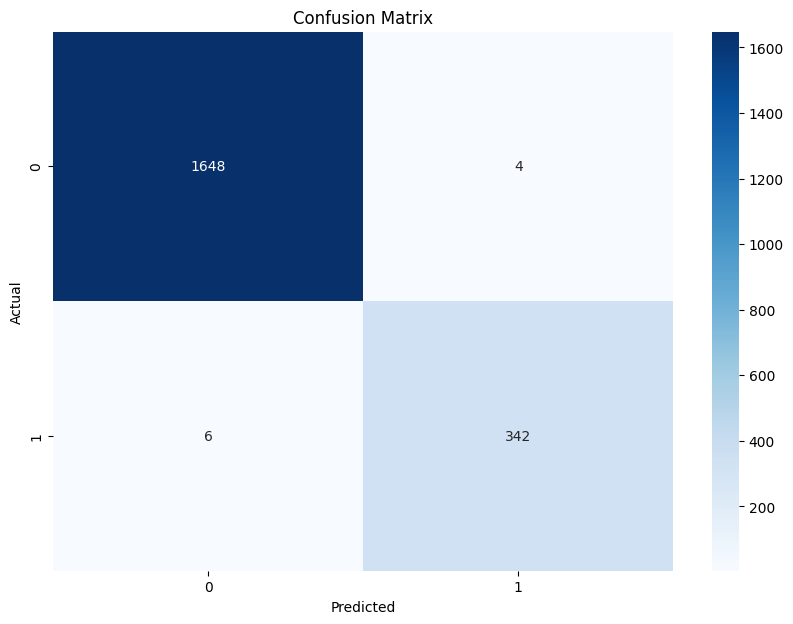

In [31]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prédictions sur les données de test
y_pred = decision_tree_model.predict(X_test)

# Convertir les valeurs continues en classes discrètes
# Ajustez les bins et les labels selon vos besoins
y_test_binned = pd.cut(y_test, bins=[-np.inf, 0.5, np.inf], labels=[0, 1])
y_pred_binned = pd.cut(y_pred, bins=[-np.inf, 0.5, np.inf], labels=[0, 1])

# Calcul de la matrice de confusion
cm = confusion_matrix(y_test_binned, y_pred_binned)

# Affichage de la matrice de confusion
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
